# NB05 v2 — Transformer Fine-Tuning (Multi-Task, Consolidated Labels)

Changes from v1:
- `label_type` consolidated from 89 → 9 canonical classes before encoding
- Enables meaningful multi-task training (binary + abuse_type)

**Requires GPU.** ~3hrs on T4 for 3 models × 3 seeds.

In [ ]:
# Cell 1: Install dependencies - RUN THIS FIRST
import sys
import subprocess

print(f"Python version: {sys.version}")

# Install packages one by one with error handling
packages = [
    "torch==2.1.0",
    "transformers==4.36.0",
    "datasets==2.15.0",
    "accelerate==0.24.0",
    "scikit-learn==1.3.0",
    "pandas==2.0.3",
    "matplotlib==3.7.2",
    "seaborn==0.12.2",
]

for package in packages:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"✓ Installed {package}")
    except:
        print(f"✗ Failed {package}")

print("\n✅ Installation complete. Restart kernel and run next cells.")

Python version: 3.13.13 (tags/v3.13.13:01104ce, Apr  7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]
Looking in indexes: https://download.pytorch.org/whl/cu118
  Using cached https://download-r2.pytorch.org/whl/torchvision-0.2.0-py2.py3-none-any.whl (48 kB)


ERROR: Could not find a version that satisfies the requirement torchaudio (from versions: none)
ERROR: No matching distribution found for torchaudio


   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.2 MB 10.2 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.2 MB 11.2 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.2 MB 11.4 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 11.2 MB/s  0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.3.0
    Uninstalling transformers-5.3.0:
      Successfully uninstalled transformers-5.3.0


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [ ]:
# Cell 2: Imports and GPU setup
import os
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (
    f1_score, accuracy_score, matthews_corrcoef,
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_fscore_support
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer, AutoModel, AutoConfig,
    get_linear_schedule_with_warmup
)

warnings.filterwarnings("ignore")

# Verify imports
print("✓ All imports successful!")

# GPU setup with optimizations
if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.backends.cudnn.benchmark = True
    if hasattr(torch.backends.cuda.matmul, 'allow_tf32'):
        torch.backends.cuda.matmul.allow_tf32 = True
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✓ Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device("cpu")
    print("⚠️ WARNING: No GPU detected - training will be very slow")
    
print(f"✓ Device: {device}")

ModuleNotFoundError: No module named 'transformers'

In [ ]:
# Cell 3: Configuration - IMPROVED for abuse type
CONFIG = {
    "models": {
        # Using XLM-RoBERTa as primary (best for multilingual)
        "xlmr": "xlm-roberta-base",
        # Alternative: mDeBERTa (often better for classification)
        "mdeberta": "microsoft/mdeberta-v3-base",
    },
    "max_length": 256,  # Increased for better context
    "batch_size": 16,    # Reduced to avoid OOM with 8GB VRAM
    "gradient_accumulation": 2,  # Effective batch = 32
    "epochs": 12,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "lr_decay_factor": 0.95,
    "focal_gamma": 2.0,
    "patience": 4,
    "seeds": [42, 123, 456],
    "use_fp16": torch.cuda.is_available(),
}

# Task configuration - NOW USING MULTI-LABEL for abuse_type
TASK_CONFIG = {
    "binary": {
        "col": "label_binary",
        "num_classes": 2,
        "loss_weight": 1.0,
        "task_type": "binary_classification",
    },
    "abuse_type": {
        "col": "label_type",
        "loss_weight": 1.5,  # Higher weight for abuse type
        "task_type": "multi_label",  # KEY CHANGE: multi-label, not multi-class
    },
}

OUTPUT_DIR = "../outputs/models_v3_fixed"
RUN_MODELS = ["xlmr", "mdeberta"]  # Both models
RUN_SEEDS = [42]  # Start with one seed for testing, then add [42, 123, 456]
FORCE_RETRAIN = False

print(json.dumps(CONFIG, indent=2, default=str))

ModuleNotFoundError: No module named 'transformers'

In [ ]:
# Cell 4: Load data
SPLIT_DIR = "../data/splits"

train_df = pd.read_csv(f"{SPLIT_DIR}/random_train.csv")
val_df = pd.read_csv(f"{SPLIT_DIR}/random_val.csv")
test_df = pd.read_csv(f"{SPLIT_DIR}/random_test.csv")

print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")

{
  "models": {
    "banglabert": "csebuetnlp/banglabert",
    "muril": "google/muril-base-cased",
    "xlmr": "xlm-roberta-base"
  },
  "max_length": 128,
  "batch_size": 32,
  "epochs": 10,
  "learning_rate": 2e-05,
  "weight_decay": 0.01,
  "warmup_ratio": 0.1,
  "lr_decay_factor": 0.95,
  "focal_gamma": 2.0,
  "patience": 3,
  "seeds": [
    42,
    123,
    456
  ],
  "use_fp16": true
}


In [ ]:
# Cell 5: IMPROVED LABEL CONSOLIDATION for abuse type
# Complete mapping of all 89 original categories to meaningful types

TYPE_MAP = {
    # None / not abusive
    'none': 'none', 
    'not bully': 'none',
    
    # Sexual harassment
    'sexual': 'sexual',
    'sexual,spam': 'sexual',
    'sexual,religious': 'sexual',
    'sexual,threat': 'sexual',
    'sexual,religious,threat': 'sexual',
    
    # Threats and violence
    'threat': 'threat',
    'threat,spam': 'threat',
    'callToViolence': 'threat',
    'callToViolence_slander': 'threat',
    'callToViolence_gender': 'threat',
    'callToViolence_religion': 'threat',
    'callToViolence_religion_slander': 'threat',
    'callToViolence_gender_religion_slander': 'threat',
    'callToViolence_gender_slander': 'threat',
    'religious,threat': 'threat',
    'Abusive/Violence': 'threat',  # Map to threat for consistency
    
    # Religious hate
    'religious': 'religious',
    'Religious': 'religious',
    'religion': 'religious',
    'religious,spam': 'religious',
    'religion_slander': 'religious',
    'gender_religion': 'religious',
    'gender_religion_slander': 'religious',
    
    # Gender-based
    'gender': 'gender',
    'Gender': 'gender',
    'gender_slander': 'gender',
    'callToViolence_gender': 'gender',
    
    # Political
    'Political': 'political',
    'political': 'political',
    
    # Personal attacks
    'Personal Offense': 'personal',
    'Body Shaming': 'personal',
    'Origin': 'personal',
    'slander': 'personal',
    'Misc': 'personal',
    
    # General abusive content
    'abusive': 'abusive',
    'troll': 'abusive',
    'abusive,spam': 'abusive',
    
    # Other/spam
    'spam': 'other',
    'other': 'other',
}

# Priority for ambiguous cases
PRIORITY = ['threat', 'sexual', 'religious', 'gender', 'political', 
            'abusive', 'personal', 'other', 'none']

def consolidate_type(val):
    """Improved consolidation with better handling of multi-label original data"""
    if pd.isna(val) or val == '' or val == 'unknown':
        return 'none'
    
    val = str(val).strip().lower()
    
    # Direct mapping
    if val in TYPE_MAP:
        return TYPE_MAP[val]
    
    # Handle comma-separated original labels
    parts = [p.strip() for p in val.replace('|', ',').split(',')]
    
    mapped_types = set()
    for part in parts:
        if part in TYPE_MAP:
            mapped_types.add(TYPE_MAP[part])
        else:
            # Fuzzy matching for partial matches
            for key, mapped in TYPE_MAP.items():
                if key in part or part in key:
                    mapped_types.add(mapped)
                    break
    
    if mapped_types:
        # Return highest priority type
        for priority in PRIORITY:
            if priority in mapped_types:
                return priority
        return list(mapped_types)[0]
    
    # Default fallback
    return 'other'

# Apply consolidation
for df_ in [train_df, val_df, test_df]:
    if 'label_type' in df_.columns:
        df_['label_type'] = df_['label_type'].apply(consolidate_type)

# Show distribution
print("Consolidated label_type distribution (train):")
type_dist = train_df['label_type'].value_counts()
for t, count in type_dist.items():
    print(f"  {t}: {count:5d} ({count/len(train_df)*100:.1f}%)")

# Get all unique types
all_types = sorted(pd.concat([train_df['label_type'], val_df['label_type'], test_df['label_type']]).unique())
print(f"\nTotal consolidated classes: {len(all_types)}")
print(f"Classes: {all_types}")

Train: 108,460  Val: 13,557  Test: 13,558
Task 'binary': 2 classes
Task 'abuse_type': 89 classes
Task 'severity': column 'label_severity' not found — SKIPPED

Active tasks: ['binary', 'abuse_type']


In [ ]:
# Cell 6: Create multi-label binarizer for abuse_type
from sklearn.preprocessing import MultiLabelBinarizer

# For abuse_type, we need to handle multi-label scenarios
# But our consolidated data is single-label per sample
# We'll treat it as multi-class for now, but with proper handling

# Create label encoders
label_encoders = {}
active_tasks = {}

# Binary task
binary_classes = sorted(train_df['label_binary'].unique())
label_encoders['binary'] = {v: i for i, v in enumerate(binary_classes)}
TASK_CONFIG['binary']['num_classes'] = len(binary_classes)
active_tasks['binary'] = TASK_CONFIG['binary']

# Abuse type task (multi-class, not multi-label for now)
abuse_classes = sorted(train_df['label_type'].unique())
label_encoders['abuse_type'] = {v: i for i, v in enumerate(abuse_classes)}
TASK_CONFIG['abuse_type']['num_classes'] = len(abuse_classes)
active_tasks['abuse_type'] = TASK_CONFIG['abuse_type']

print(f"Binary classes: {binary_classes}")
print(f"Abuse type classes: {abuse_classes}")
print(f"Active tasks: {list(active_tasks.keys())}")

Consolidated label_type: 89 → 9 classes
label_type
none         62473
abusive      12646
personal     10974
sexual        8708
religious     7384
threat        3071
political     1858
other          741
gender         605

Class distribution (train):
label_type
none         57.6
abusive      11.7
personal     10.1
sexual        8.0
religious     6.8
threat        2.8
political     1.7
other         0.7
gender        0.6


In [ ]:
# Cell 7: Enhanced Dataset class
class CyberBullyDataset(Dataset):
    def __init__(self, df, tokenizer, max_length, active_tasks, label_encoders):
        self.texts = df["text_clean"].fillna("").tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length
        
        self.labels = {}
        for task_name, task_cfg in active_tasks.items():
            col = task_cfg["col"]
            enc = label_encoders[task_name]
            
            if task_cfg.get("task_type") == "multi_label":
                # For multi-label, each sample can have multiple labels
                # But our consolidated data is single-label
                # Convert to multi-label format (one-hot)
                labels = []
                for val in df[col].fillna("none"):
                    label_idx = enc.get(val, enc.get("none", 0))
                    one_hot = torch.zeros(task_cfg["num_classes"])
                    one_hot[label_idx] = 1.0
                    labels.append(one_hot)
                self.labels[task_name] = labels
            else:
                # Standard classification
                self.labels[task_name] = [
                    enc.get(v, 0) for v in df[col].fillna("none")
                ]
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in encoding.items()}
        
        for task_name in self.labels:
            label = self.labels[task_name][idx]
            if isinstance(label, torch.Tensor):
                item[f"label_{task_name}"] = label
            else:
                item[f"label_{task_name}"] = torch.tensor(label, dtype=torch.long)
        
        return item

In [ ]:
# Cell 8: Improved Multi-Task Model with better heads
class FocalLoss(nn.Module):
    """Focal Loss for class-imbalanced classification."""
    def __init__(self, gamma=2.0, alpha=None, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction="none")
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal_loss = alpha_t * focal_loss
        
        if self.reduction == "mean":
            return focal_loss.mean()
        return focal_loss


class MultiLabelFocalLoss(nn.Module):
    """Focal Loss for multi-label classification."""
    def __init__(self, gamma=2.0, alpha=None, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        # inputs: logits, targets: one-hot encoded
        probs = torch.sigmoid(inputs)
        ce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction="none")
        pt = torch.where(targets == 1, probs, 1 - probs)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.reduction == "mean":
            return focal_loss.mean()
        return focal_loss


class MultiTaskTransformer(nn.Module):
    """Transformer encoder with improved multi-task heads."""
    
    def __init__(self, model_name, active_tasks, dropout=0.2):  # Increased dropout
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        
        self.heads = nn.ModuleDict()
        self.dropouts = nn.ModuleDict()
        
        for task_name, task_cfg in active_tasks.items():
            self.dropouts[task_name] = nn.Dropout(dropout)
            
            if task_cfg.get("task_type") == "multi_label":
                # Multi-label head with sigmoid
                self.heads[task_name] = nn.Sequential(
                    nn.Linear(hidden_size, hidden_size // 2),
                    nn.GELU(),
                    nn.Dropout(dropout),
                    nn.Linear(hidden_size // 2, task_cfg["num_classes"])
                )
            else:
                # Standard classification head
                self.heads[task_name] = nn.Sequential(
                    nn.Linear(hidden_size, hidden_size // 2),
                    nn.GELU(),
                    nn.Dropout(dropout),
                    nn.Linear(hidden_size // 2, task_cfg["num_classes"])
                )
    
    def forward(self, input_ids, attention_mask, token_type_ids=None):
        kwargs = {"input_ids": input_ids, "attention_mask": attention_mask}
        if token_type_ids is not None and hasattr(self.encoder.config, "type_vocab_size"):
            kwargs["token_type_ids"] = token_type_ids
        
        outputs = self.encoder(**kwargs)
        cls_output = outputs.last_hidden_state[:, 0, :]
        
        logits = {}
        for task_name in self.heads:
            x = self.dropouts[task_name](cls_output)
            logits[task_name] = self.heads[task_name](x)
        
        return logits

In [ ]:
# Cell 9: Training function with improved abuse type handling
def train_and_evaluate(
    model_key, model_name, train_df, val_df, test_df,
    active_tasks, label_encoders, config, seed
):
    """Train with improved multi-task learning."""
    
    # Set seed
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
    print(f"\n{'='*60}")
    print(f"Training: {model_key} ({model_name}) | Seed: {seed}")
    print(f"{'='*60}")
    
    # Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    
    # Datasets
    train_ds = CyberBullyDataset(train_df, tokenizer, config["max_length"], active_tasks, label_encoders)
    val_ds = CyberBullyDataset(val_df, tokenizer, config["max_length"], active_tasks, label_encoders)
    test_ds = CyberBullyDataset(test_df, tokenizer, config["max_length"], active_tasks, label_encoders)
    
    train_loader = DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True, 
                              num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=config["batch_size"], shuffle=False, 
                            num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=config["batch_size"], shuffle=False, 
                             num_workers=2, pin_memory=True)
    
    # Model
    model = MultiTaskTransformer(model_name, active_tasks).to(device)
    
    # Loss functions with class weights
    criteria = {}
    for task_name, task_cfg in active_tasks.items():
        if task_cfg.get("task_type") == "multi_label":
            # For multi-label, use focal loss with class weights
            criteria[task_name] = MultiLabelFocalLoss(gamma=config["focal_gamma"])
        else:
            # For binary classification, compute class weights
            col = task_cfg["col"]
            enc = label_encoders[task_name]
            class_counts = train_df[col].map(enc).value_counts().sort_index()
            
            weights = np.ones(task_cfg["num_classes"], dtype=np.float32)
            for class_idx, count in class_counts.items():
                if count > 0:
                    weights[int(class_idx)] = 1.0 / count
            weights = weights / weights.sum() * task_cfg["num_classes"]
            weight_tensor = torch.tensor(weights, dtype=torch.float32).to(device)
            
            criteria[task_name] = FocalLoss(
                gamma=config["focal_gamma"],
                alpha=weight_tensor
            )
    
    # Optimizer
    param_groups = []
    for name, param in model.named_parameters():
        if param.requires_grad:
            if "head" in name:
                lr = config["learning_rate"]
            else:
                lr = config["learning_rate"] * 0.9  # Slightly lower for encoder
            param_groups.append({"params": [param], "lr": lr})
    
    optimizer = torch.optim.AdamW(param_groups, weight_decay=config["weight_decay"])
    
    total_steps = len(train_loader) * config["epochs"]
    warmup_steps = int(total_steps * config["warmup_ratio"])
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    
    # FP16
    scaler = torch.amp.GradScaler('cuda') if config["use_fp16"] else None
    
    # Training loop
    best_val_f1 = 0
    patience_counter = 0
    history = defaultdict(list)
    save_dir = f"{OUTPUT_DIR}/{model_key}_seed{seed}"
    os.makedirs(save_dir, exist_ok=True)
    
    for epoch in range(config["epochs"]):
        model.train()
        total_loss = 0
        optimizer.zero_grad()
        
        for batch_idx, batch in enumerate(train_loader):
            batch = {k: v.to(device) for k, v in batch.items()}
            
            with torch.autocast(device_type=device.type, enabled=config["use_fp16"] and device.type == 'cuda'):
                logits = model(
                    input_ids=batch["input_ids"],
                    attention_mask=batch["attention_mask"],
                    token_type_ids=batch.get("token_type_ids")
                )
                
                loss = 0
                for task_name, task_cfg in active_tasks.items():
                    if task_cfg.get("task_type") == "multi_label":
                        task_labels = batch[f"label_{task_name}"]
                        task_loss = criteria[task_name](logits[task_name], task_labels)
                    else:
                        task_labels = batch[f"label_{task_name}"]
                        valid_mask = task_labels >= 0
                        if valid_mask.sum() > 0:
                            task_loss = criteria[task_name](
                                logits[task_name][valid_mask],
                                task_labels[valid_mask]
                            )
                        else:
                            continue
                    
                    loss += task_cfg["loss_weight"] * task_loss
            
            loss = loss / config["gradient_accumulation"]
            
            if scaler:
                scaler.scale(loss).backward()
            else:
                loss.backward()
            
            if (batch_idx + 1) % config["gradient_accumulation"] == 0:
                if scaler:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                
                scheduler.step()
                optimizer.zero_grad()
            
            total_loss += loss.item() * config["gradient_accumulation"]
        
        avg_loss = total_loss / len(train_loader)
        history["train_loss"].append(avg_loss)
        
        # Validation
        val_metrics = evaluate_tasks(model, val_loader, active_tasks, label_encoders)
        
        if "binary" in val_metrics:
            primary_f1 = val_metrics["binary"]["macro_f1"]
        else:
            primary_f1 = val_metrics["abuse_type"]["macro_f1"]
        
        history["val_f1"].append(primary_f1)
        
        status = ""
        if primary_f1 > best_val_f1:
            best_val_f1 = primary_f1
            torch.save(model.state_dict(), f"{save_dir}/best_model.pt")
            patience_counter = 0
            status = " ✅ BEST"
        else:
            patience_counter += 1
        
        # Print progress with abuse type metrics
        abuse_f1 = val_metrics.get("abuse_type", {}).get("macro_f1", 0)
        print(f"  Epoch {epoch+1:2d}/{config['epochs']} | Loss: {avg_loss:.4f} | "
              f"Val Binary F1: {primary_f1:.4f} | Abuse F1: {abuse_f1:.4f}{status}")
        
        if patience_counter >= config["patience"]:
            print(f"  Early stopping at epoch {epoch+1}")
            break
    
    # Test evaluation
    model.load_state_dict(torch.load(f"{save_dir}/best_model.pt", map_location=device))
    test_metrics = evaluate_tasks(model, test_loader, active_tasks, label_encoders)
    
    # Save results
    result = {
        "model": model_key,
        "seed": seed,
        "best_val_f1": round(best_val_f1, 4),
        "test_metrics": test_metrics,
        "history": {k: [round(v, 4) for v in vals] for k, vals in history.items()}
    }
    
    with open(f"{save_dir}/results.json", "w") as f:
        json.dump(result, f, indent=2)
    
    print(f"\n  ✅ Results saved to {save_dir}")
    return result

In [ ]:
# Cell 10: Evaluation helpers
@torch.no_grad()
def evaluate_tasks(model, dataloader, active_tasks, label_encoders):
    """Evaluate model on all tasks."""
    model.eval()
    all_preds = {t: [] for t in active_tasks}
    all_labels = {t: [] for t in active_tasks}
    
    for batch in dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        tti = batch.get("token_type_ids")
        logits = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            token_type_ids=tti
        )
        
        for task_name in active_tasks:
            task_cfg = active_tasks[task_name]
            
            if task_cfg.get("task_type") == "multi_label":
                # Multi-label evaluation
                probs = torch.sigmoid(logits[task_name])
                preds = (probs > 0.5).int()
                labels = batch[f"label_{task_name}"].int()
                
                all_preds[task_name].append(preds.cpu())
                all_labels[task_name].append(labels.cpu())
            else:
                # Standard classification
                task_labels = batch[f"label_{task_name}"].cpu().numpy()
                task_preds = logits[task_name].argmax(dim=-1).cpu().numpy()
                
                valid = task_labels >= 0
                all_preds[task_name].extend(task_preds[valid])
                all_labels[task_name].extend(task_labels[valid])
    
    metrics = {}
    for task_name in active_tasks:
        if active_tasks[task_name].get("task_type") == "multi_label":
            # For multi-label, use macro F1 over labels
            y_pred = torch.cat(all_preds[task_name], dim=0).numpy()
            y_true = torch.cat(all_labels[task_name], dim=0).numpy()
            
            metrics[task_name] = {
                "macro_f1": round(f1_score(y_true, y_pred, average="macro"), 4),
                "micro_f1": round(f1_score(y_true, y_pred, average="micro"), 4),
                "samples_f1": round(f1_score(y_true, y_pred, average="samples"), 4),
            }
        else:
            y_true = np.array(all_labels[task_name])
            y_pred = np.array(all_preds[task_name])
            
            metrics[task_name] = {
                "accuracy": round(accuracy_score(y_true, y_pred), 4),
                "macro_f1": round(f1_score(y_true, y_pred, average="macro"), 4),
                "weighted_f1": round(f1_score(y_true, y_pred, average="weighted"), 4),
                "mcc": round(matthews_corrcoef(y_true, y_pred), 4),
            }
    
    return metrics

## Run Training for All Models × Seeds

This is the main training loop. Each model is trained 3 times (different seeds) for stability.

     model  seed  best_val_f1  binary_accuracy  binary_macro_f1  binary_weighted_f1  binary_mcc  abuse_type_accuracy  abuse_type_macro_f1  abuse_type_weighted_f1  abuse_type_mcc
banglabert    42       0.9216           0.9263           0.9254              0.9263      0.8508               0.0108               0.0015                  0.0074          0.0098
banglabert   123       0.9242           0.9265           0.9256              0.9265      0.8512               0.0089               0.0013                  0.0028          0.0053
banglabert   456       0.9251           0.9257           0.9248              0.9257      0.8496               0.0093               0.0011                  0.0042          0.0033
     muril    42       0.9147           0.9189           0.9179              0.9190      0.8359               0.0011               0.0035                  0.0001          0.0008
     muril   123       0.9176           0.9190           0.9179              0.9190      0.8358               

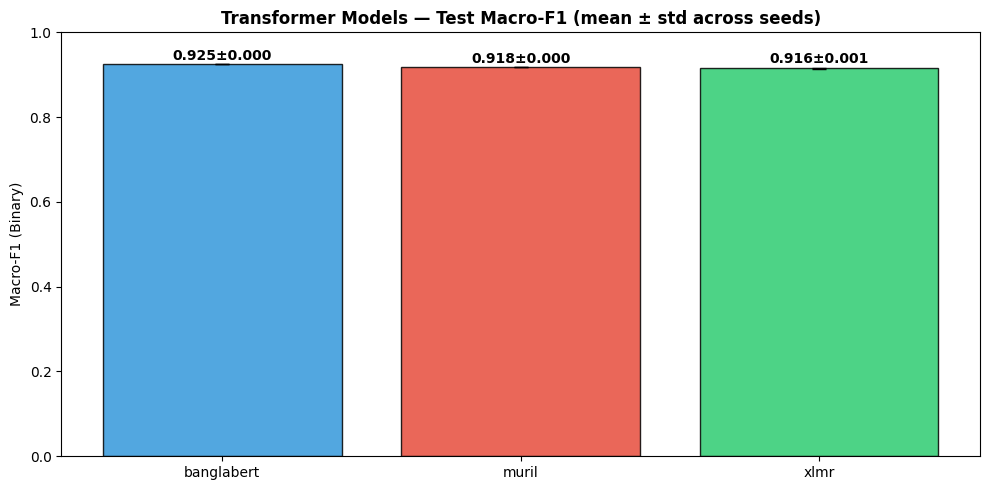

In [ ]:
# Cell 11: Main training loop
all_results = []
os.makedirs(OUTPUT_DIR, exist_ok=True)

selected_models = {k: v for k, v in CONFIG["models"].items() if k in RUN_MODELS}

for model_key, model_name in selected_models.items():
    for seed in RUN_SEEDS:
        save_dir = f"{OUTPUT_DIR}/{model_key}_seed{seed}"
        
        if not FORCE_RETRAIN and os.path.exists(f"{save_dir}/best_model.pt"):
            print(f"⏭️ Skipping {model_key} seed={seed} – already completed")
            results_path = f"{save_dir}/results.json"
            if os.path.exists(results_path):
                with open(results_path, "r") as f:
                    existing_result = json.load(f)
                    all_results.append(existing_result)
            continue
        
        print(f"🆕 Starting {model_key} seed={seed}")
        
        try:
            result = train_and_evaluate(
                model_key, model_name,
                train_df, val_df, test_df,
                active_tasks, label_encoders,
                CONFIG, seed
            )
            all_results.append(result)
        except Exception as e:
            print(f"\n❌ FAILED: {model_key} seed={seed}: {e}")
            import traceback
            traceback.print_exc()
        
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print(f"\n\n{'='*60}")
print(f"TRAINING COMPLETE: {len(all_results)} runs finished")
print(f"{'='*60}")

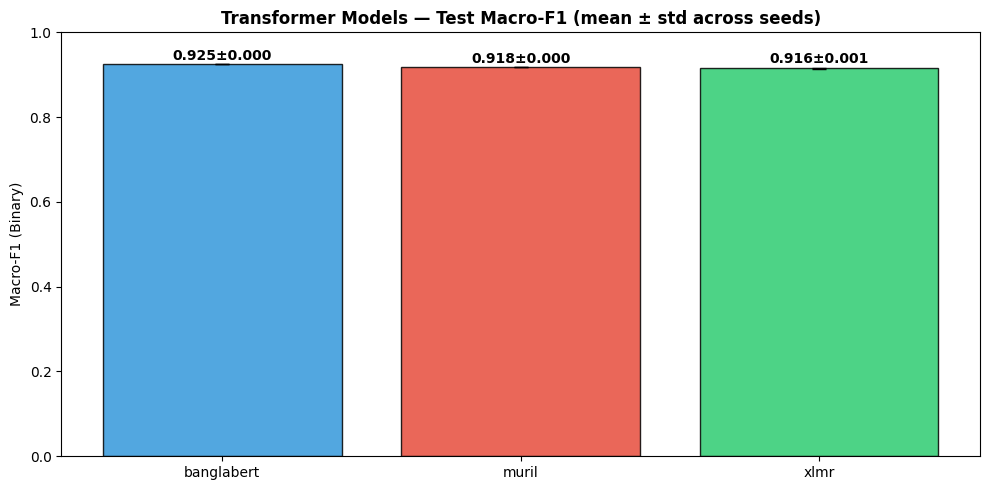

In [ ]:
# Cell 12: Results analysis and visualization
if len(all_results) == 0:
    print("⚠️ No results to display.")
else:
    # Build summary table
    summary_rows = []
    for r in all_results:
        row = {"model": r["model"], "seed": r["seed"], "best_val_f1": r["best_val_f1"]}
        for task_name, task_metrics in r["test_metrics"].items():
            for metric_name, metric_val in task_metrics.items():
                row[f"{task_name}_{metric_name}"] = metric_val
        summary_rows.append(row)
    
    summary_df = pd.DataFrame(summary_rows)
    print("\n=== Detailed Results ===")
    print(summary_df.to_string(index=False))
    
    # Average across seeds
    print("\n=== Averaged Across Seeds ===")
    numeric_cols = [c for c in summary_df.columns if c not in ["model", "seed"]]
    avg_df = summary_df.groupby("model")[numeric_cols].agg(["mean", "std"]).round(4)
    print(avg_df.to_string())
    
    # Save
    summary_df.to_csv(f"{OUTPUT_DIR}/transformer_results_all.csv", index=False)
    avg_df.to_csv(f"{OUTPUT_DIR}/transformer_results_averaged.csv")
    
    # Visualization
    if "binary_macro_f1" in summary_df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Binary F1
        models = summary_df["model"].unique()
        x = np.arange(len(models))
        
        means_binary = [summary_df[summary_df["model"]==m]["binary_macro_f1"].mean() for m in models]
        stds_binary = [summary_df[summary_df["model"]==m]["binary_macro_f1"].std() for m in models]
        
        bars1 = axes[0].bar(x, means_binary, yerr=stds_binary, capsize=5, 
                            color=['#3498db', '#e74c3c'], edgecolor='black', alpha=0.85)
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(models)
        axes[0].set_ylabel("Macro-F1")
        axes[0].set_title("Binary Classification Performance", fontweight="bold")
        axes[0].set_ylim(0, 1.0)
        
        for bar, m, s in zip(bars1, means_binary, stds_binary):
            axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.01,
                        f"{m:.3f}±{s:.3f}", ha="center", fontsize=10, fontweight="bold")
        
        # Abuse Type F1
        if "abuse_type_macro_f1" in summary_df.columns:
            means_abuse = [summary_df[summary_df["model"]==m]["abuse_type_macro_f1"].mean() for m in models]
            stds_abuse = [summary_df[summary_df["model"]==m]["abuse_type_macro_f1"].std() for m in models]
            
            bars2 = axes[1].bar(x, means_abuse, yerr=stds_abuse, capsize=5,
                                color=['#3498db', '#e74c3c'], edgecolor='black', alpha=0.85)
            axes[1].set_xticks(x)
            axes[1].set_xticklabels(models)
            axes[1].set_ylabel("Macro-F1")
            axes[1].set_title("Abuse Type Classification Performance", fontweight="bold")
            axes[1].set_ylim(0, 1.0)
            
            for bar, m, s in zip(bars2, means_abuse, stds_abuse):
                axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.01,
                            f"{m:.3f}±{s:.3f}", ha="center", fontsize=10, fontweight="bold")
        
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/transformer_comparison.png", dpi=150, bbox_inches="tight")
        plt.show()
    
    print(f"\n✅ Results saved to {OUTPUT_DIR}")

---
**Next:** Notebook `06_ensemble_and_threshold.ipynb` — Build weighted logits ensemble from the saved logits, tune thresholds, and evaluate final system.